# Experiment 7 analysis

Reads the consolidated CSVs under `data/outputs/Experiment 7/_analysis/`. Run-level tables come from `runs_cache.csv`; score distributions and GMM analysis come from `evaluation_scores.csv`.

The notebook does not read raw experiment output folders.


In [1]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "outputs").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks and aux scripts"
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from hardware_equivalence import normalize_latency

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
plt.rcParams["figure.dpi"] = 110
from scipy import stats
from sklearn.mixture import GaussianMixture

ALL_MODELS = [
    "patchcore", "padim", "subspacead", "stfpm",
    "csflow", "draem", "rd4ad",
]

CROISSANT_CATEGORIES = ["croissant_dataset"]

EXP_ROOT = PROJECT_ROOT / "data" / "outputs" / "Experiment 7"
ANALYSIS_DIR = EXP_ROOT / "_analysis"
RUNS_CSV = ANALYSIS_DIR / "runs_cache.csv"
SCORES_CSV = ANALYSIS_DIR / "evaluation_scores.csv"

print(f"Runs CSV: {RUNS_CSV}")
print(f"Scores CSV: {SCORES_CSV}")


Runs CSV: c:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection\data\outputs\Experiment 7\_analysis\runs_cache.csv
Scores CSV: c:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection\data\outputs\Experiment 7\_analysis\evaluation_scores.csv


In [ ]:
RUN_CACHE_COLUMNS = [
    "experiment", "experiment_dir", "model", "category", "gpu_name",
    "threshold_value", "threshold_mode", "warmup_frames", "calibration_frames",
    "streaming_frames", "n_predicted_anomalies", "ng_rate", "mean_score",
    "median_score", "std_score", "p95_score", "p99_score", "max_score",
    "mean_latency_ms", "throughput_fps", "_report_mtime_ns", "_report_size",
    "_frames_mtime_ns", "_frames_size",
]


def _first_gpu_name(report: dict) -> str | None:
    devices = (
        report.get("hardware", {})
        .get("accelerator", {})
        .get("cuda_devices", [])
    )
    if devices:
        return devices[0].get("name")
    return None


def _model_name(report: dict) -> str | None:
    raw_model = report.get("model", {}).get("name")
    if raw_model is None:
        return None
    return str(raw_model).replace("anomalib_", "")


def _category_from_report(report: dict) -> str | None:
    input_path = report.get("stream", {}).get("input_path")
    if input_path:
        return Path(input_path).name
    return None


def _cache_row_from_coldstart_report(report_path: Path) -> dict | None:
    run_dir = report_path.parent.parent
    report = json.loads(report_path.read_text(encoding="utf-8"))
    model = _model_name(report)
    category = _category_from_report(report)
    if model not in ALL_MODELS or category is None:
        return None
    frames_path = report_path.parent / "frames.jsonl"
    report_stat = report_path.stat()
    frames_stat = frames_path.stat() if frames_path.exists() else None
    threshold = report.get("threshold", {})
    warmup = report.get("warmup", {})
    evaluation = report.get("evaluation", {})
    return {
        "experiment": run_dir.name,
        "experiment_dir": str(run_dir.resolve()),
        "model": model,
        "category": category,
        "gpu_name": _first_gpu_name(report),
        "threshold_value": report.get("threshold_used") or threshold.get("threshold"),
        "threshold_mode": report.get("threshold_mode") or threshold.get("mode"),
        "warmup_frames": warmup.get("warmup_steps") or evaluation.get("warmup_frames_excluded"),
        "calibration_frames": threshold.get("calibration_steps") or evaluation.get("threshold_calibration_frames_excluded"),
        "streaming_frames": evaluation.get("n_evaluation_frames") or report.get("n_scored"),
        "n_predicted_anomalies": report.get("n_predicted_anomalies"),
        "ng_rate": report.get("ng_rate"),
        "mean_score": report.get("mean_score"),
        "median_score": report.get("median_score"),
        "std_score": report.get("std_score"),
        "p95_score": report.get("p95_score"),
        "p99_score": report.get("p99_score"),
        "max_score": report.get("max_score"),
        "mean_latency_ms": report.get("mean_latency_ms"),
        "throughput_fps": report.get("throughput_fps"),
        "_report_mtime_ns": report_stat.st_mtime_ns,
        "_report_size": report_stat.st_size,
        "_frames_mtime_ns": frames_stat.st_mtime_ns if frames_stat else None,
        "_frames_size": frames_stat.st_size if frames_stat else None,
    }


def append_missing_run_cache_rows(exp_root: Path, cache_path: Path) -> int:
    """Append only cold-start runs that are absent from the run cache CSV."""
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    if cache_path.exists() and cache_path.stat().st_size > 0:
        cached_experiments = pd.read_csv(cache_path, usecols=["experiment"])
        existing = set(cached_experiments["experiment"].dropna().astype(str))
    else:
        existing = set()

    rows = []
    for report_path in sorted(exp_root.glob("coldstart_*/report_bundle/report.json")):
        if report_path.parent.parent.name in existing:
            continue
        row = _cache_row_from_coldstart_report(report_path)
        if row is not None:
            rows.append(row)
    if not rows:
        if not cache_path.exists():
            pd.DataFrame(columns=RUN_CACHE_COLUMNS).to_csv(cache_path, index=False)
        print(f"Cache already complete: {cache_path}")
        return 0

    new_df = pd.DataFrame(rows, columns=RUN_CACHE_COLUMNS)
    write_header = not cache_path.exists() or cache_path.stat().st_size == 0
    new_df.to_csv(cache_path, mode="a", header=write_header, index=False)
    print(f"Appended {len(new_df)} missing rows to {cache_path}.")
    print(new_df.groupby("model").size().sort_index().to_string())
    return len(new_df)


append_missing_run_cache_rows(EXP_ROOT, RUNS_CSV)


In [2]:
df = pd.read_csv(RUNS_CSV)
score_df = pd.read_csv(SCORES_CSV, low_memory=False)
normalize_latency(df)
MODELS_PRESENT = sorted(df["model"].dropna().unique()) if not df.empty else []
print(f"Loaded {len(df)} consolidated run rows across models: {MODELS_PRESENT}")
print(f"Loaded {len(score_df)} consolidated evaluation score rows.")


Loaded 7 consolidated run rows across models: ['csflow', 'draem', 'padim', 'patchcore', 'rd4ad', 'stfpm', 'subspacead']
Loaded 74963 consolidated evaluation score rows.


## 1. Runs per model

Count of output folders found in `Experiment 7/` for each model. Only one category (`croissant_dataset`) was run.

In [3]:
runs_per_cat = (
    df.groupby(["category", "model"]).size().unstack(fill_value=0)
    .reindex(index=CROISSANT_CATEGORIES, columns=ALL_MODELS, fill_value=0)
)
runs_per_cat.index.name = "category"
runs_per_cat.loc["TOTAL"] = runs_per_cat.sum(axis=0)
runs_per_cat

model,patchcore,padim,subspacead,stfpm,csflow,draem,rd4ad
category,,,,,,,
croissant_dataset,1,1,1,1,1,1,1
TOTAL,1,1,1,1,1,1,1


## 2. Per-model summary table

Headline numbers for each run. Because the croissant capture is unlabeled, the only "detection" figure is the **NG rate** — the fraction of evaluation frames that the model flagged as anomalous at its calibrated threshold.

$$
\text{NG rate} = \frac{\#\{\,\text{frames with}\ \widehat{y}_t = 1\,\}}{\#\{\,\text{evaluation frames}\,\}}
$$

Threshold (and so NG rate) is set by the POT/quantile rule used during streaming; warm-up and calibration frames are excluded.

In [4]:
SUMMARY_COLS = [
    "threshold_mode", "threshold_value",
    "warmup_frames", "calibration_frames", "streaming_frames",
    "n_predicted_anomalies", "ng_rate",
    "mean_score", "median_score", "p95_score", "p99_score", "max_score",
    "mean_latency_ms", "throughput_fps",
]

summary = (
    df.sort_values("model")
    .set_index("model")[SUMMARY_COLS]
)
summary

,threshold_mode,threshold_value,warmup_frames,calibration_frames,streaming_frames,n_predicted_anomalies,ng_rate,mean_score,median_score,p95_score,p99_score,max_score,mean_latency_ms,throughput_fps
model,,,,,,,,,,,,,,
csflow,pot,195096.2651,300,500,10709,4,0.0004,378.3554,17.2424,37.3172,126.0419,1392280.7500,31.6761,28.0800
draem,pot,0.9999,300,500,10709,6,0.0006,0.9985,0.9987,0.9995,0.9997,1.0000,20.1103,41.8330
padim,pot,211.4411,300,500,10709,0,0.0000,30.7324,26.0789,58.9670,100.1442,201.6555,1.1096,169.4484
patchcore,pot,67.8725,300,500,10709,1,0.0001,34.3640,33.0963,43.1060,51.4080,69.2400,46.1885,19.1912
rd4ad,pot,0.0053,300,500,10709,21,0.0020,0.0007,0.0006,0.0016,0.0030,0.0137,5.6297,103.1276
stfpm,pot,0.0141,300,500,10709,67,0.0063,0.0049,0.0045,0.0082,0.0127,0.0314,1.7620,178.4821
subspacead,pot,8.7383,300,500,10709,5,0.0005,2.9257,2.8093,3.7959,4.9131,11.8738,101.7959,9.5263


## 3. Score distribution per model

Histogram of per-frame anomaly scores over the evaluation phase (warm-up and threshold-calibration excluded). The vertical dashed line marks the calibrated threshold used at inference; everything to the right of it counted toward the NG rate.

**What to look for** — a clean detector on an unlabeled stream typically produces a **bimodal** score histogram: a dense "OK" mode on the left, a sparse "NG" mode on the right, with an empty valley in between (the threshold should fall inside that valley). A unimodal distribution suggests the model cannot separate normal vs anomalous appearance on this dataset.

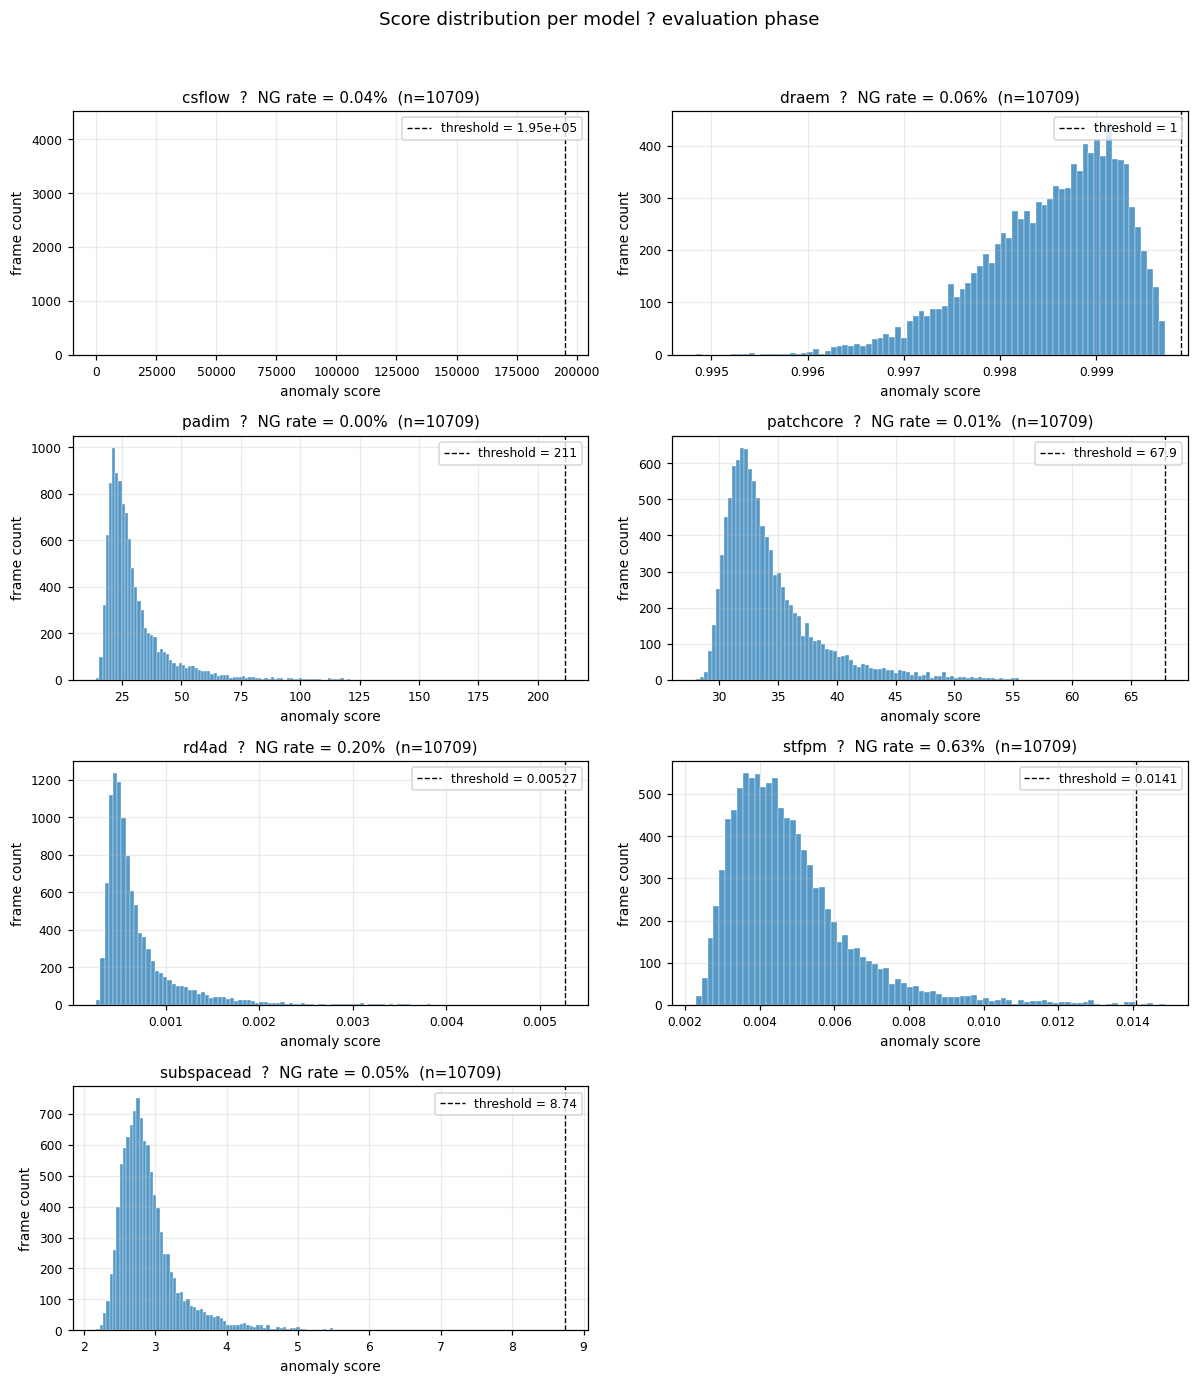

In [5]:
def load_evaluation_scores(experiment: str, model: str | None = None) -> np.ndarray:
    sub = score_df[score_df["experiment"] == experiment]
    if model is not None:
        sub = sub[sub["model"] == model]
    return sub.sort_values("idx")["score"].to_numpy(dtype=float)


HIST_COLS = 2
n_models = len(MODELS_PRESENT)
nrows = math.ceil(n_models / HIST_COLS) if n_models else 1
fig, axes = plt.subplots(
    nrows, HIST_COLS,
    figsize=(HIST_COLS * 5.5, nrows * 3.2),
    squeeze=False,
)
fig.suptitle("Score distribution per model ? evaluation phase", fontsize=12)

for i, model in enumerate(MODELS_PRESENT):
    ax = axes[i // HIST_COLS][i % HIST_COLS]
    row = df[df["model"] == model].iloc[0]
    scores = load_evaluation_scores(row["experiment"], model)
    if scores.size == 0:
        ax.set_visible(False)
        continue
    upper = float(np.percentile(scores, 99.5))
    lower = float(np.min(scores))
    ax.hist(scores, bins=80, range=(lower, max(upper, lower + 1e-9)),
            color="tab:blue", alpha=0.75, edgecolor="white", linewidth=0.3)
    thr = row["threshold_value"]
    if pd.notna(thr):
        ax.axvline(float(thr), color="black", lw=0.9, ls="--",
                   label=f"threshold = {float(thr):.3g}")
    ng_rate = row["ng_rate"]
    ax.set_title(f"{model}  ?  NG rate = {ng_rate*100:.2f}%  (n={scores.size})", fontsize=10)
    ax.set_xlabel("anomaly score", fontsize=9)
    ax.set_ylabel("frame count", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.25)

for j in range(n_models, nrows * HIST_COLS):
    axes[j // HIST_COLS][j % HIST_COLS].set_visible(False)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### 3b. Same histograms on log-y

Log-scaled y-axis to make the *tail* (candidate NG cluster) visible — raw counts of the OK mode swamp the histogram on a linear axis.

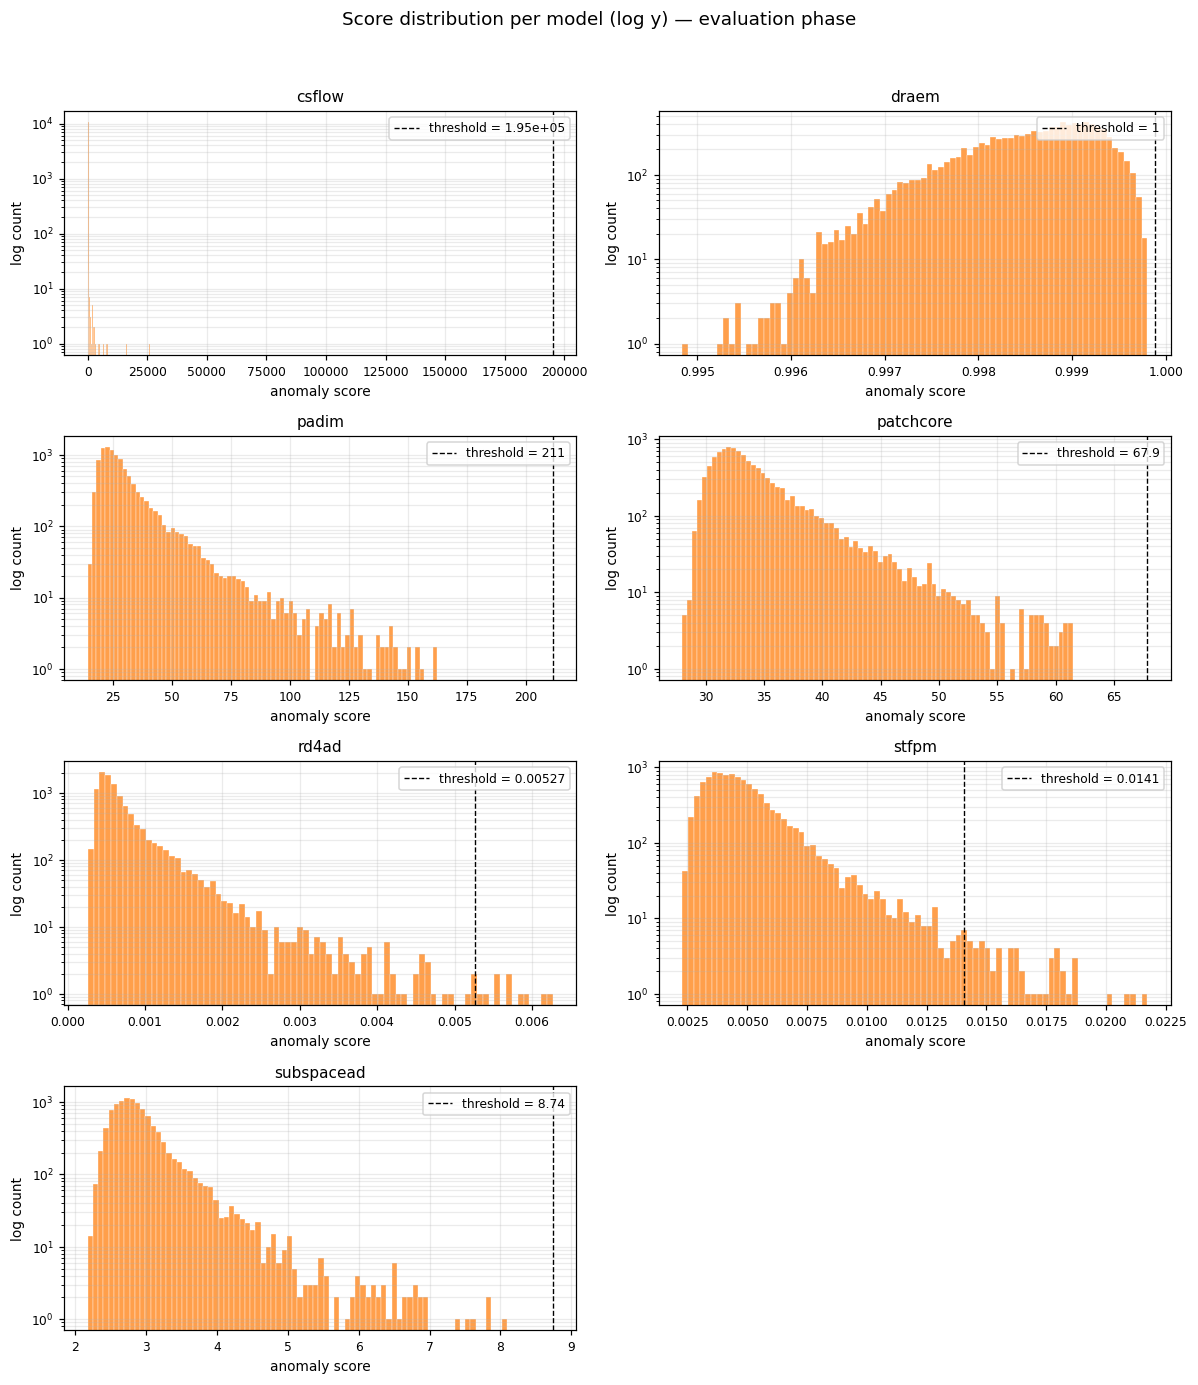

In [6]:
fig, axes = plt.subplots(
    nrows, HIST_COLS,
    figsize=(HIST_COLS * 5.5, nrows * 3.2),
    squeeze=False,
)
fig.suptitle("Score distribution per model (log y) \u2014 evaluation phase", fontsize=12)

for i, model in enumerate(MODELS_PRESENT):
    ax = axes[i // HIST_COLS][i % HIST_COLS]
    row = df[df["model"] == model].iloc[0]
    scores = load_evaluation_scores(row["experiment"], model)
    if scores.size == 0:
        ax.set_visible(False)
        continue
    upper = float(np.percentile(scores, 99.9))
    lower = float(np.min(scores))
    ax.hist(scores, bins=80, range=(lower, max(upper, lower + 1e-9)),
            color="tab:orange", alpha=0.75, edgecolor="white", linewidth=0.3)
    ax.set_yscale("log")
    thr = row["threshold_value"]
    if pd.notna(thr):
        ax.axvline(float(thr), color="black", lw=0.9, ls="--",
                   label=f"threshold = {float(thr):.3g}")
    ax.set_title(f"{model}", fontsize=10)
    ax.set_xlabel("anomaly score", fontsize=9)
    ax.set_ylabel("log count", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.25, which="both")

for j in range(n_models, nrows * HIST_COLS):
    axes[j // HIST_COLS][j % HIST_COLS].set_visible(False)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### 3c. Selected models for the thesis (DRAEM / PaDiM / STFPM)

The same histograms restricted to the three architectures that anchor the discussion in §4.4 of the thesis. Models were picked for *qualitative* reasons, not for headline detection quality:

- **DRAEM** — score distribution piles up close to the calibrated threshold rather than producing a clean bimodal shape, so the POT cut sits inside the bulk and the few NG predictions are score-wise indistinguishable from many OK ones.
- **PaDiM** — never crossed the threshold on the croissant stream, so the NG count is exactly $0$. Useful to show what a "too conservative" calibration looks like on a unimodal score histogram.
- **STFPM** — the most permissive model, with $67$ NG flags. Its tail is wide enough that the threshold falls well below the highest scores, which is why it dominates the single-model bucket of §6.

The figure stores both the linear and the log-$y$ view side by side so the OK bulk and the NG tail are visible without having to consult two separate plots.


In [ ]:
SELECTED_MODELS = ["draem", "padim", "stfpm"]
FIG_OUT_SELECTED = (
    PROJECT_ROOT / "Latex document" / "figs" / "results"
    / "exp7_score_distribution_selected.png"
)

fig, axes = plt.subplots(
    len(SELECTED_MODELS), 2,
    figsize=(11, 3.0 * len(SELECTED_MODELS)),
    squeeze=False,
)
fig.suptitle(
    "Score distribution \u2014 selected models for the thesis (linear vs log y)",
    fontsize=12,
)

for row_idx, model in enumerate(SELECTED_MODELS):
    row = df[df["model"] == model].iloc[0]
    scores = load_evaluation_scores(row["experiment"], model)
    if scores.size == 0:
        for col in range(2):
            axes[row_idx][col].set_visible(False)
        continue
    thr = row["threshold_value"]
    ng_rate = row["ng_rate"]
    lower = float(np.min(scores))

    # --- Linear y (left column) ---
    ax_lin = axes[row_idx][0]
    upper = float(np.percentile(scores, 99.5))
    ax_lin.hist(
        scores, bins=80, range=(lower, max(upper, lower + 1e-9)),
        color="tab:blue", alpha=0.75, edgecolor="white", linewidth=0.3,
    )
    if pd.notna(thr):
        ax_lin.axvline(
            float(thr), color="black", lw=0.9, ls="--",
            label=f"threshold = {float(thr):.3g}",
        )
    ax_lin.set_title(
        f"{model}  \u2014  linear y  (NG rate = {ng_rate*100:.2f}%, n={scores.size})",
        fontsize=10,
    )
    ax_lin.set_xlabel("anomaly score", fontsize=9)
    ax_lin.set_ylabel("frame count", fontsize=9)
    ax_lin.legend(fontsize=8, loc="upper right")
    ax_lin.grid(alpha=0.25)
    ax_lin.tick_params(labelsize=8)

    # --- Log y (right column) ---
    ax_log = axes[row_idx][1]
    upper_log = float(np.percentile(scores, 99.9))
    ax_log.hist(
        scores, bins=80, range=(lower, max(upper_log, lower + 1e-9)),
        color="tab:orange", alpha=0.75, edgecolor="white", linewidth=0.3,
    )
    ax_log.set_yscale("log")
    if pd.notna(thr):
        ax_log.axvline(
            float(thr), color="black", lw=0.9, ls="--",
            label=f"threshold = {float(thr):.3g}",
        )
    ax_log.set_title(f"{model}  \u2014  log y", fontsize=10)
    ax_log.set_xlabel("anomaly score", fontsize=9)
    ax_log.set_ylabel("log count", fontsize=9)
    ax_log.legend(fontsize=8, loc="upper right")
    ax_log.grid(alpha=0.25, which="both")
    ax_log.tick_params(labelsize=8)

fig.tight_layout(rect=[0, 0, 1, 0.96])

FIG_OUT_SELECTED.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_OUT_SELECTED, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIG_OUT_SELECTED}")


## 4. Streaming scores over frame order

Per-frame anomaly score across the evaluation phase. Without labels we colour every point grey and only mark frames that crossed the threshold ("predicted NG") in red.

- **Y axis** is the score **min-max normalized to [0, 1] per plot** (the dashed threshold line is normalized with the same min/max so its position is meaningful within the plot).
- **X axis** keeps the original online visualization: frame order within the evaluation phase.


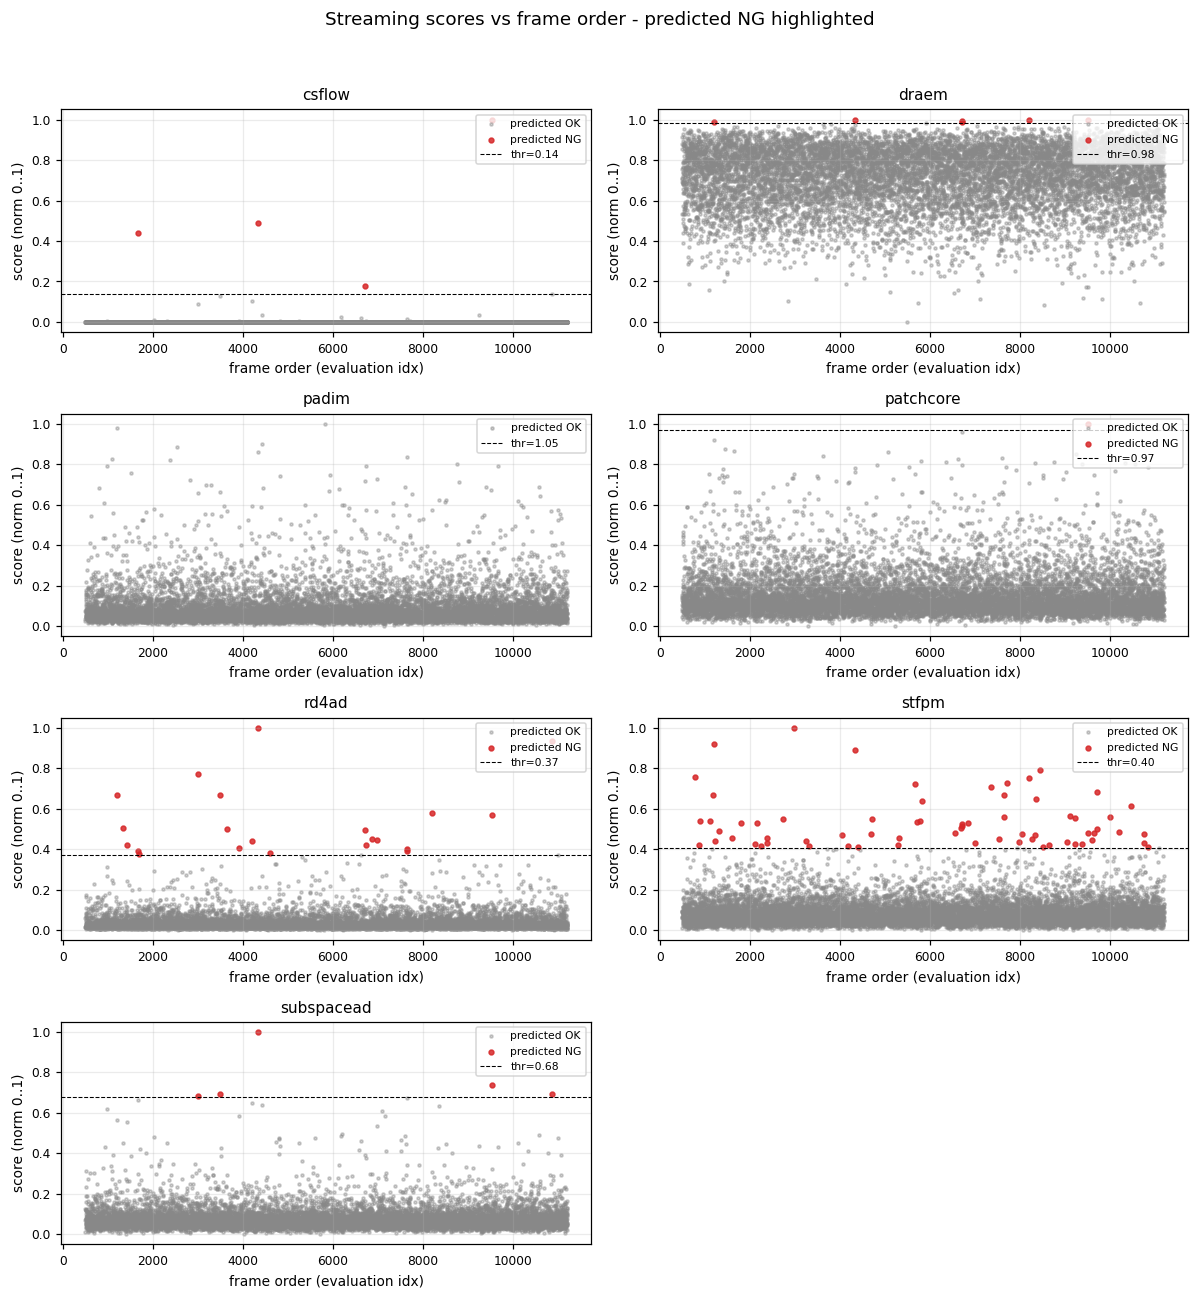

In [7]:
def load_streaming_records(experiment: str, model: str | None = None) -> pd.DataFrame:
    sub = score_df[score_df["experiment"] == experiment]
    if model is not None:
        sub = sub[sub["model"] == model]
    return sub.sort_values("idx")


SCATTER_COLS = 2
fig, axes = plt.subplots(
    nrows, SCATTER_COLS,
    figsize=(SCATTER_COLS * 5.5, nrows * 3.0),
    squeeze=False,
)
fig.suptitle("Streaming scores vs frame order - predicted NG highlighted", fontsize=12)

for i, model in enumerate(MODELS_PRESENT):
    ax = axes[i // SCATTER_COLS][i % SCATTER_COLS]
    row = df[df["model"] == model].iloc[0]
    recs = load_streaming_records(row["experiment"], model)
    if recs.empty:
        ax.set_visible(False)
        continue
    idx = recs["idx"].to_numpy(dtype=int)
    scores = recs["score"].to_numpy(dtype=float)
    preds = recs["pred_label"].fillna(-1).to_numpy(dtype=int)

    finite = np.isfinite(scores)
    if not finite.any():
        ax.set_visible(False)
        continue
    s_min = float(scores[finite].min())
    s_max = float(scores[finite].max())
    denom = (s_max - s_min) if s_max > s_min else 1.0
    scores_norm = (scores - s_min) / denom

    ng = preds == 1
    ax.scatter(idx[~ng], scores_norm[~ng], s=4, c="#888888", alpha=0.40, label="predicted OK")
    if ng.any():
        ax.scatter(idx[ng], scores_norm[ng], s=10, c="tab:red", alpha=0.85, label="predicted NG")
    thr = row["threshold_value"]
    if pd.notna(thr):
        thr_norm = (float(thr) - s_min) / denom
        ax.axhline(thr_norm, color="black", lw=0.7, ls="--", label=f"thr={thr_norm:.2f}")
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"{model}", fontsize=10)
    ax.set_xlabel("frame order (evaluation idx)", fontsize=9)
    ax.set_ylabel("score (norm 0..1)", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(alpha=0.25)

for j in range(n_models, nrows * SCATTER_COLS):
    axes[j // SCATTER_COLS][j % SCATTER_COLS].set_visible(False)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## 5. Unsupervised separation proxies

Without labels we cannot compute AUROC or F1, but we can ask: *does the model produce two well-separated score modes?* That is the working assumption behind **Yu et al. (2023), "Anomaly Detection with Score Distribution Discrimination"** — they train detectors with an **Overlap Loss** that pushes the OK and NG score histograms apart, and use the same overlap quantity as an unsupervised quality signal at inference. We compute two label-free proxies inspired by that view:

### 5a. Bimodality coefficient (SAS / Pfister et al. 2013)

Closed-form statistic from sample skew $g$ and excess kurtosis $k$:

$$
\mathrm{BC} = \frac{g^{2} + 1}{k + \frac{3(n-1)^{2}}{(n-2)(n-3)}}
$$

A perfect uniform distribution gives $\mathrm{BC} = 5/9 \approx 0.555$; values **above** that threshold are commonly read as evidence of bimodality (multi-cluster structure in the score histogram). Cheap, requires no model fitting.

### 5b. Two-component GMM standardized separation

Fit a 2-component Gaussian mixture to the (log-)scores. Let $(\mu_1, \sigma_1)$ and $(\mu_2, \sigma_2)$ be the two component parameters with $\mu_2 > \mu_1$ (low mode = OK candidate, high mode = NG candidate). Report:

$$
D = \frac{\mu_2 - \mu_1}{\sqrt{\tfrac{1}{2}(\sigma_1^{2} + \sigma_2^{2})}}
\quad \text{and} \quad
\pi_{\text{NG}} = \text{mixture weight of the high mode.}
$$

$D$ is a Cohen-style *d* between the two latent clusters: $D \gtrsim 2$ means the modes are well separated (low overlap, useful detector); $D \lesssim 1$ means the score histogram looks like one mode and the threshold is essentially cutting noise. $\pi_{\text{NG}}$ is a *model-internal* estimate of the NG rate that does **not** depend on the operational threshold — comparing $\pi_{\text{NG}}$ against the threshold-driven NG rate from §2 tells us whether the threshold is too aggressive/conservative for what the score distribution actually contains.

In [8]:
def bimodality_coefficient(x: np.ndarray) -> float:
    n = x.size
    if n < 4:
        return float("nan")
    g = float(stats.skew(x, bias=False))
    k = float(stats.kurtosis(x, fisher=True, bias=False))  # excess kurtosis
    correction = 3.0 * (n - 1) ** 2 / ((n - 2) * (n - 3))
    denom = k + correction
    if denom <= 0:
        return float("nan")
    return (g * g + 1.0) / denom


def gmm_two_component(x: np.ndarray, *, log_transform: bool = True, seed: int = 0) -> dict:
    """Fit GMM(k=2) and return standardized separation D and mixture weights."""
    if x.size < 50 or np.std(x) == 0:
        return {"D": float("nan"), "pi_low": float("nan"), "pi_high": float("nan"),
                "mu_low": float("nan"), "mu_high": float("nan"),
                "sigma_low": float("nan"), "sigma_high": float("nan")}
    data = x.astype(float)
    if log_transform:
        shift = max(0.0, -float(np.min(data)) + 1e-6)
        data = np.log1p(data + shift)
    gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=seed,
                         n_init=4, max_iter=300).fit(data.reshape(-1, 1))
    means = gmm.means_.ravel()
    sigmas = np.sqrt(gmm.covariances_.ravel())
    weights = gmm.weights_.ravel()
    order = np.argsort(means)  # low, high
    mu_lo, mu_hi = means[order]
    s_lo, s_hi = sigmas[order]
    w_lo, w_hi = weights[order]
    D = (mu_hi - mu_lo) / math.sqrt(0.5 * (s_lo ** 2 + s_hi ** 2)) if (s_lo + s_hi) > 0 else float("nan")
    return {"D": float(D), "pi_low": float(w_lo), "pi_high": float(w_hi),
            "mu_low": float(mu_lo), "mu_high": float(mu_hi),
            "sigma_low": float(s_lo), "sigma_high": float(s_hi)}


rows_sep = []
for model in MODELS_PRESENT:
    row = df[df["model"] == model].iloc[0]
    scores = load_evaluation_scores(row["experiment"], model)
    bc = bimodality_coefficient(scores)
    gmm_res = gmm_two_component(scores)
    rows_sep.append({
        "model": model,
        "n_scores": int(scores.size),
        "bimodality_coef": bc,
        "bimodal?": "\u2713" if (not math.isnan(bc) and bc > 5 / 9) else "\u00d7",
        "gmm_D": gmm_res["D"],
        "gmm_pi_high": gmm_res["pi_high"],
        "ng_rate (§2)": float(row["ng_rate"]),
    })

sep_df = pd.DataFrame(rows_sep).set_index("model")
sep_df


,n_scores,bimodality_coef,bimodal?,gmm_D,gmm_pi_high,ng_rate (§2)
model,,,,,,
csflow,10709,0.8843,✓,1.2580,0.0562,0.0004
draem,10709,0.4812,×,0.0093,0.6622,0.0006
padim,10709,0.6247,✓,1.8655,0.2483,0.0000
patchcore,10709,0.5927,✓,1.8741,0.2294,0.0001
rd4ad,10709,0.5130,×,1.1023,0.0080,0.0020
stfpm,10709,0.4919,×,1.6850,0.0464,0.0063
subspacead,10709,0.5088,×,1.5293,0.1606,0.0005


### 5c. GMM(k=2) overlay on the score histogram

Visual check: the two fitted Gaussian components are plotted on top of the score histogram (KDE-style). When $D \gtrsim 2$ the two bells should sit on the OK mode and the NG tail respectively; when $D$ is small the two components collapse onto the same mode and the fit is meaningless.

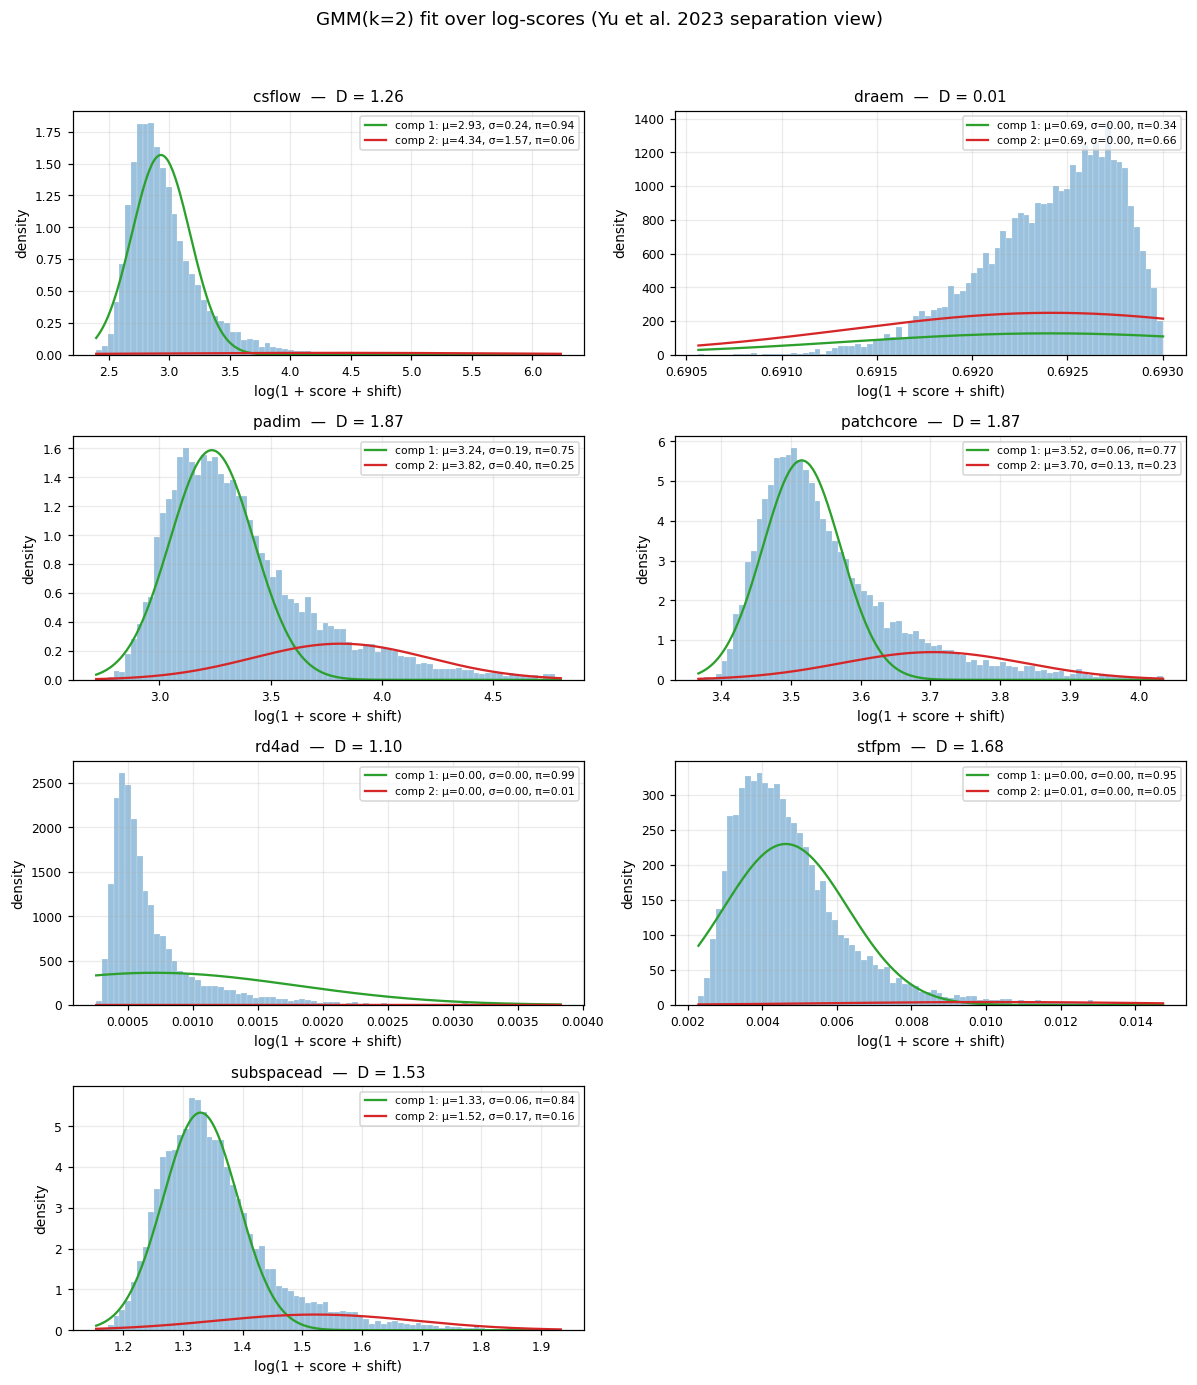

In [9]:
fig, axes = plt.subplots(
    nrows, HIST_COLS,
    figsize=(HIST_COLS * 5.5, nrows * 3.2),
    squeeze=False,
)
fig.suptitle("GMM(k=2) fit over log-scores (Yu et al. 2023 separation view)", fontsize=12)

for i, model in enumerate(MODELS_PRESENT):
    ax = axes[i // HIST_COLS][i % HIST_COLS]
    row = df[df["model"] == model].iloc[0]
    scores = load_evaluation_scores(row["experiment"], model)
    if scores.size == 0:
        ax.set_visible(False)
        continue
    shift = max(0.0, -float(np.min(scores)) + 1e-6)
    log_s = np.log1p(scores + shift)
    gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=0,
                         n_init=4, max_iter=300).fit(log_s.reshape(-1, 1))
    means = gmm.means_.ravel(); sigmas = np.sqrt(gmm.covariances_.ravel()); weights = gmm.weights_.ravel()
    order = np.argsort(means)
    lo_x = float(np.min(log_s)); hi_x = float(np.percentile(log_s, 99.5))
    grid = np.linspace(lo_x, hi_x, 400)
    ax.hist(log_s, bins=80, range=(lo_x, hi_x), density=True,
            color="tab:blue", alpha=0.45, edgecolor="white", linewidth=0.3)
    colors = ["tab:green", "tab:red"]
    for j, idx in enumerate(order):
        pdf = weights[idx] * stats.norm.pdf(grid, means[idx], sigmas[idx])
        ax.plot(grid, pdf, color=colors[j], lw=1.5,
                label=f"comp {j+1}: μ={means[idx]:.2f}, σ={sigmas[idx]:.2f}, π={weights[idx]:.2f}")
    D = (means[order[1]] - means[order[0]]) / math.sqrt(0.5 * (sigmas[order[0]] ** 2 + sigmas[order[1]] ** 2))
    ax.set_title(f"{model}  \u2014  D = {D:.2f}", fontsize=10)
    ax.set_xlabel("log(1 + score + shift)", fontsize=9)
    ax.set_ylabel("density", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(alpha=0.25)

for j in range(n_models, nrows * HIST_COLS):
    axes[j // HIST_COLS][j % HIST_COLS].set_visible(False)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## 6. Cross-model NG consensus

Grouping of evaluation frames by the number of models that crossed their POT threshold on that frame. With no ground-truth labels available on `croissant_dataset`, the most operationally meaningful signal is **agreement across architectures**: a frame flagged by several independent detectors is a stronger anomaly candidate than one flagged by a single model.

For every evaluation frame we count distinct models with `pred_label == 1`. The frame's *consensus level* is therefore an integer in $\{1, 2, \ldots, 7\}$ (frames with $0$ are dropped because they were never flagged).

- **Table** below lists every flagged `image_id` together with the consensus level and the participating models.
- **Figure** arranges the frames in columns from $7/7$ down to $1/7$ models. Each column stacks the actual crops so that the visual quality of high-consensus candidates can be compared directly against single-model picks. Columns are capped to a fixed number of visible thumbnails; if the bucket holds more, the extra count is reported in the column title.


,n_models,image_id,models
0,6,Cam_1_Combined_Frames_6888_6895_Ts_17758154897...,"csflow, draem, patchcore, rd4ad, stfpm, subspa..."
1,5,Cam_1_Combined_Frames_15518_15525_Ts_177581718...,"csflow, draem, rd4ad, stfpm, subspacead"
2,4,Cam_1_Combined_Frames_6232_6239_Ts_17758153605...,"csflow, draem, rd4ad, stfpm"
3,3,Cam_1_Combined_Frames_12672_12679_Ts_177581662...,"draem, rd4ad, stfpm"
4,3,Cam_1_Combined_Frames_12744_12751_Ts_177581664...,"rd4ad, stfpm, subspacead"
...,...,...,...
72,1,Cam_1_Combined_Frames_7952_7959_Ts_17758156992...,stfpm
73,1,Cam_1_Combined_Frames_8056_8063_Ts_17758157197...,stfpm
74,1,Cam_1_Combined_Frames_8144_8151_Ts_17758157370...,stfpm
75,1,Cam_1_Combined_Frames_8688_8695_Ts_17758158441...,stfpm


Frames flagged per consensus level:


k of 7 models,7,6,5,4,3,2,1
frames,0,1,1,1,5,5,64


Unique flagged frames (union across the 7 models): 77


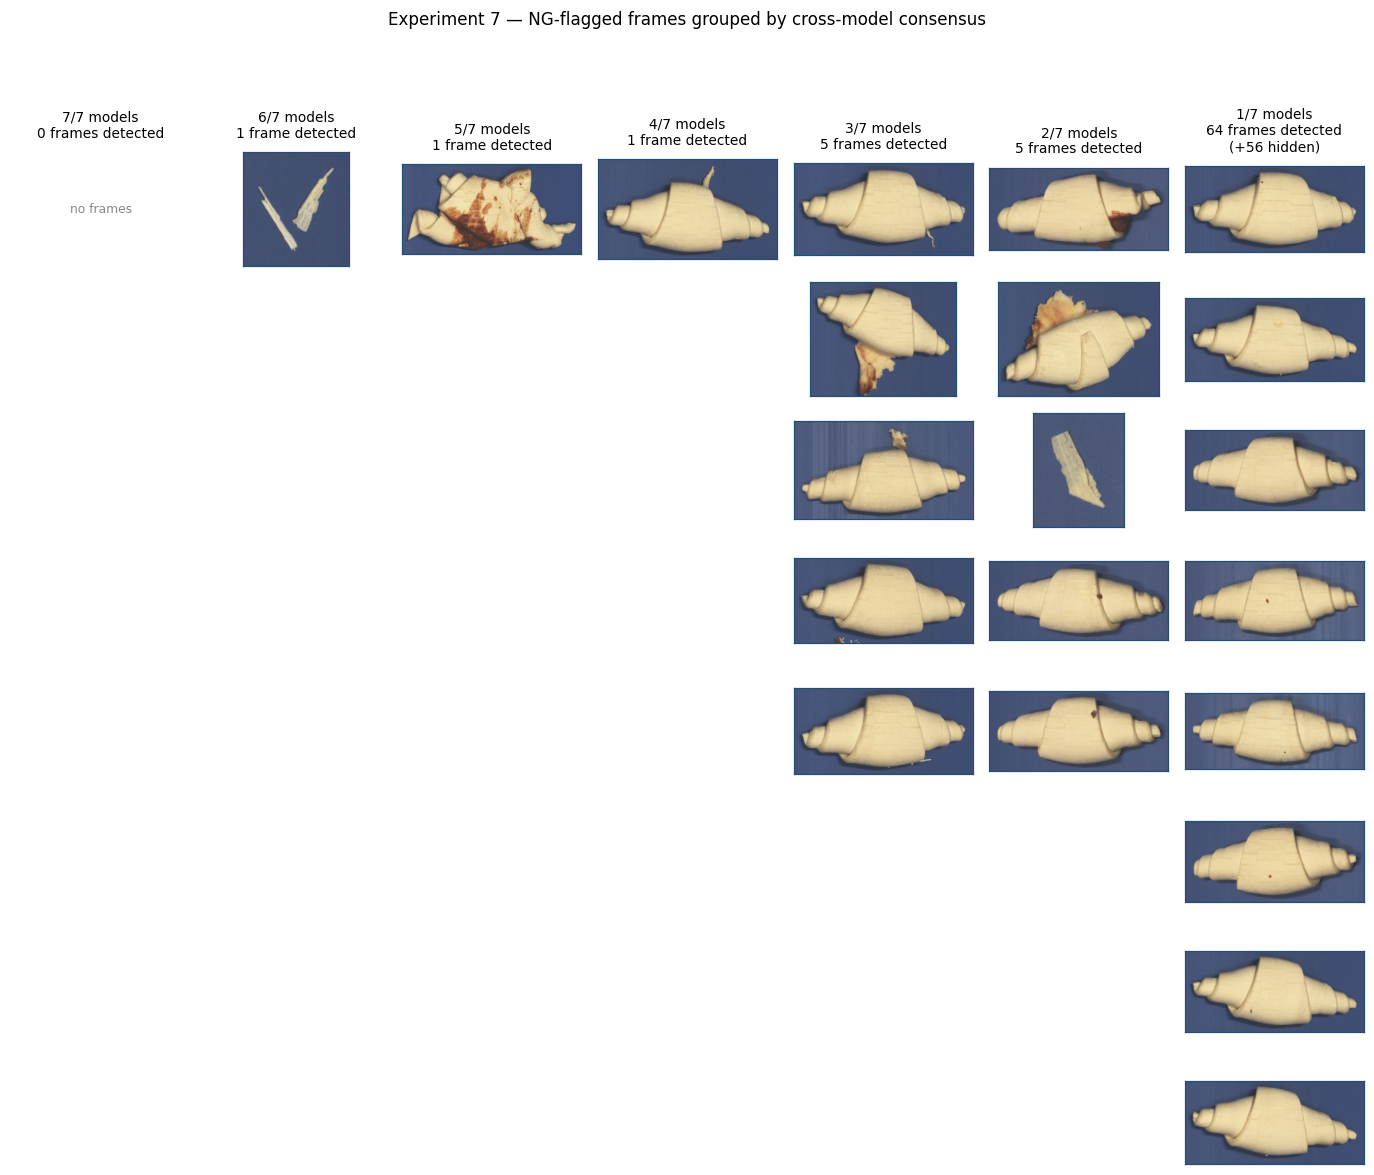

Saved figure -> c:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection\Latex document\figs\results\exp7_consensus_grid.png


In [10]:
from PIL import Image

CROP_DIR = PROJECT_ROOT / "data" / "Croissant_dataset" / "data_vandemoortele_crops"
FIG_OUT = PROJECT_ROOT / "Latex document" / "figs" / "results" / "exp7_consensus_grid.png"

N_MODELS = 7
MAX_THUMBS_PER_COL = 8  # cap visible thumbnails per consensus column

# 1. Per-frame consensus
ng = score_df[score_df["pred_label"] == 1].copy()
consensus = (
    ng.groupby("image_id")["model"]
      .apply(lambda s: sorted(set(s)))
      .rename("models")
      .to_frame()
)
consensus["n_models"] = consensus["models"].apply(len)
consensus = consensus.sort_values(["n_models", "image_id"], ascending=[False, True])

# 2. Table view
table = consensus.reset_index()[["n_models", "image_id", "models"]]
table["models"] = table["models"].apply(lambda lst: ", ".join(lst))
display(table)

# Distribution row by consensus level
dist = (
    consensus["n_models"].value_counts()
    .reindex(range(1, N_MODELS + 1), fill_value=0)
    .sort_index(ascending=False)
    .rename("frames")
    .to_frame()
)
dist.index.name = "k of 7 models"
print("Frames flagged per consensus level:")
display(dist.T)
print(f"Unique flagged frames (union across the {N_MODELS} models): {len(consensus)}")

# 3. Figure: columns from 7/7 down to 1/7, stacked thumbnails per bucket
k_levels = list(range(N_MODELS, 0, -1))
groups = {k: consensus.index[consensus["n_models"] == k].tolist() for k in k_levels}

n_rows = max(1, min(MAX_THUMBS_PER_COL, max((len(v) for v in groups.values()), default=1)))
n_cols = len(k_levels)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 1.8, n_rows * 1.3 + 0.6),
    squeeze=False,
)

for col_idx, k in enumerate(k_levels):
    ids = groups[k]
    visible = ids[:MAX_THUMBS_PER_COL]
    extra = len(ids) - len(visible)

    for row_idx in range(n_rows):
        ax = axes[row_idx][col_idx]
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        if row_idx < len(visible):
            img_id = visible[row_idx]
            img_path = CROP_DIR / f"{img_id}.jpg"
            if img_path.exists():
                ax.imshow(Image.open(img_path))
            else:
                ax.text(0.5, 0.5, "missing", ha="center", va="center", fontsize=7)
                ax.set_facecolor("#f0f0f0")
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor("#1f4e79")
                spine.set_linewidth(0.8)
        elif row_idx == 0 and len(visible) == 0:
            # keep the first row's axis visible so the empty column still has a title
            ax.text(0.5, 0.5, "no frames", ha="center", va="center",
                    fontsize=8, color="#888888")
        else:
            ax.set_visible(False)

    title = f"{k}/{N_MODELS} models\n{len(ids)} frame{'s' if len(ids) != 1 else ''} detected"
    if extra > 0:
        title += f"\n(+{extra} hidden)"
    axes[0][col_idx].set_title(title, fontsize=9, pad=10)

fig.suptitle(
    "Experiment 7 \u2014 NG-flagged frames grouped by cross-model consensus",
    fontsize=11,
)
fig.tight_layout(rect=[0, 0, 1, 0.94])

FIG_OUT.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_OUT, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved figure -> {FIG_OUT}")


### 6b. Single-model NG frames (appendix grid)

The consensus grid in §6 only renders the first eight thumbnails of the $1/7$ column. This cell completes that column with the remaining $56$ frames that exactly one model flagged as NG, paginated into pages of $28$ ($4$ columns $\times$ $7$ rows). Each crop is labelled with its original reference ID and the score assigned by the flagging model. The pages are saved to `figs/results/exp7_single_model_ng_appendix_p*.png` and reproduced in Appendix B of the thesis.


In [ ]:
import textwrap

OUT_DIR = PROJECT_ROOT / "Latex document" / "figs" / "results"
N_COLS_APP = 4
N_ROWS_APP = 7
PER_PAGE = N_COLS_APP * N_ROWS_APP        # 28 thumbnails per page
SHOWN_IN_CONSENSUS = 8                     # already rendered in the §6 grid

# Reuse the consensus frame from §6 if present, otherwise rebuild it.
try:
    consensus
except NameError:
    ng = score_df[score_df["pred_label"] == 1].copy()
    consensus = (
        ng.groupby("image_id")["model"].apply(lambda s: sorted(set(s)))
          .rename("models").to_frame()
    )
    consensus["n_models"] = consensus["models"].apply(len)
    consensus = consensus.sort_values(["n_models", "image_id"], ascending=[False, True])

ng_pred = score_df[score_df["pred_label"] == 1]
single_ids = consensus.index[consensus["n_models"] == 1].tolist()
hidden_ids = single_ids[SHOWN_IN_CONSENSUS:]

records = []
for img_id in hidden_ids:
    sub = ng_pred[ng_pred["image_id"] == img_id]
    records.append((img_id, sub["model"].iloc[0], float(sub["score"].iloc[0])))
print(f"Single-model NG frames beyond the consensus grid: {len(records)}")


def _wrap_id(img_id):
    return "\n".join(textwrap.wrap(img_id, width=24, break_long_words=True))


n_pages = (len(records) + PER_PAGE - 1) // PER_PAGE
for page in range(n_pages):
    chunk = records[page * PER_PAGE:(page + 1) * PER_PAGE]
    fig, axes = plt.subplots(
        N_ROWS_APP, N_COLS_APP,
        figsize=(N_COLS_APP * 2.6, N_ROWS_APP * 2.5),
        squeeze=False,
    )
    fig.suptitle(
        f"Experiment 7 \u2014 single-model NG frames (1/7 consensus), "
        f"page {page + 1} of {n_pages}",
        fontsize=12,
    )
    for cell_idx in range(PER_PAGE):
        r, c = divmod(cell_idx, N_COLS_APP)
        ax = axes[r][c]
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        if cell_idx < len(chunk):
            img_id, model, score = chunk[cell_idx]
            img_path = CROP_DIR / f"{img_id}.jpg"
            if img_path.exists():
                ax.imshow(Image.open(img_path))
            else:
                ax.text(0.5, 0.5, "missing", ha="center", va="center", fontsize=7)
                ax.set_facecolor("#f0f0f0")
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor("#1f4e79")
                spine.set_linewidth(0.8)
            ax.set_title(_wrap_id(img_id), fontsize=5.0, pad=3, family="monospace")
            ax.set_xlabel(f"{model} \u00b7 score = {score:.4g}", fontsize=6.5, labelpad=2)
        else:
            ax.set_visible(False)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    out_path = OUT_DIR / f"exp7_single_model_ng_appendix_p{page + 1}.png"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved {out_path.name} ({len(chunk)} frames)")


## References

- **Yu, M., Wang, T., Zhang, R., Ding, K., Zhao, Y., He, J., Hu, T., & Cheng, J. (2023).** *Anomaly Detection with Score Distribution Discrimination*. KDD '23. [arXiv:2306.14403](https://arxiv.org/abs/2306.14403). — introduces *Overlap loss* and motivates evaluating an anomaly detector by how separated its normal vs anomaly score distributions are; their Section 2 explicitly discusses estimating these distributions when anomaly labels are scarce or absent.
- **Pfister, R., Schwarz, K. A., Janczyk, M., Dale, R., & Freeman, J. (2013).** *Good things peak in pairs: a note on the bimodality coefficient*. Frontiers in Psychology, 4, 700. — closed-form bimodality coefficient with the $5/9$ uniform-distribution cutoff used in §5a.
- **Hartigan, J. A., & Hartigan, P. M. (1985).** *The dip test of unimodality*. The Annals of Statistics, 13(1), 70–84. — non-parametric alternative for testing whether a one-dimensional sample is unimodal; useful as a complement to BC when sample size is large.